<a href="https://colab.research.google.com/github/panda1823/Customer-Churn-Analytics/blob/main/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Customer-Churn-Analytics**

Install libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn


Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Load Dataset

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

Preview data

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.duplicated().sum()

np.int64(0)

**Data Cleaning**

In [ ]:
#check structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#Check missing values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#Convert datatype
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
#Fill missing values

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [ ]:
#Remove customerID column

df.drop("customerID", axis=1, inplace=True)

In [ ]:
#Check duplicates

df.duplicated().sum()

np.int64(22)

Encode Categorical Columns

In [ ]:
#Convert churn to numeric

df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [ ]:
#Convert gender

df["gender"] = df["gender"].map({"Male":1,"Female":0})

In [ ]:
#updated dataset

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,1,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,1,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


**Exploratory Data Analysis (EDA)**

Churn Distribution

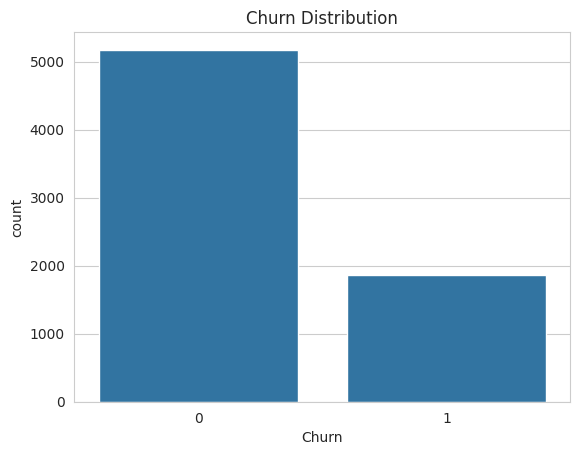

In [ ]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

-   Insight:
High churn = business risk

Churn by Contract Type

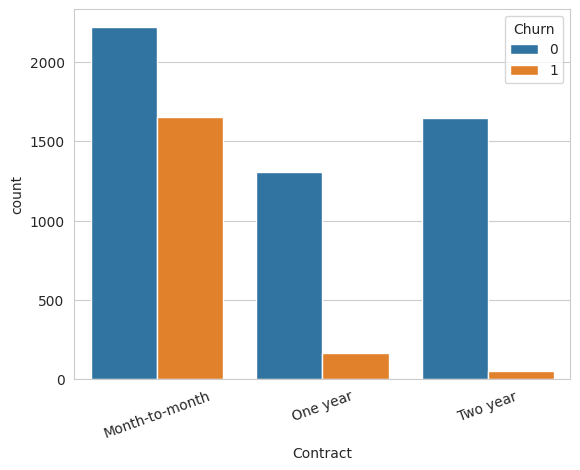

In [ ]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.show()

-    insight :  Month-to-month customers churn more

Churn by Internet Service

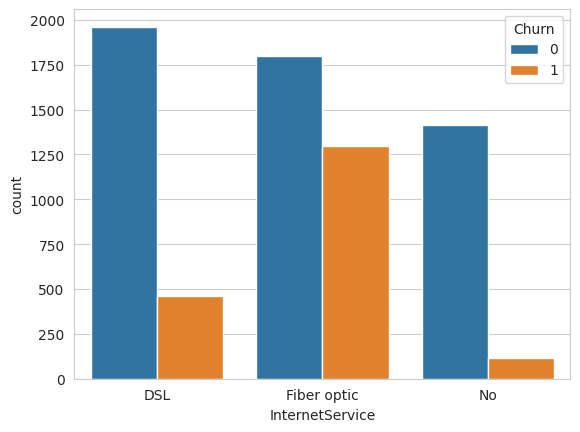

In [ ]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

-    insight: Fiber users churn more

Tenure vs Churn

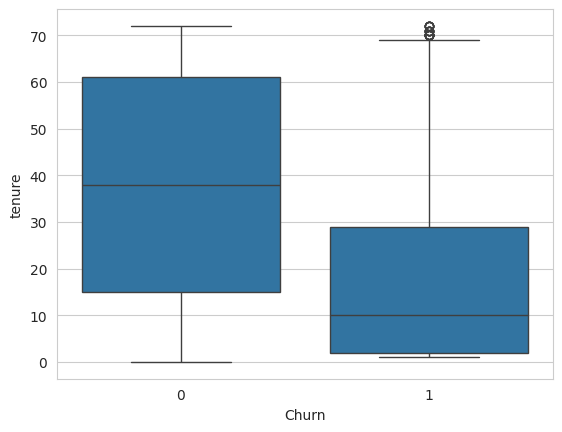

In [ ]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

-   insight:  Low-tenure customers churn early

Monthly Charges vs Churn

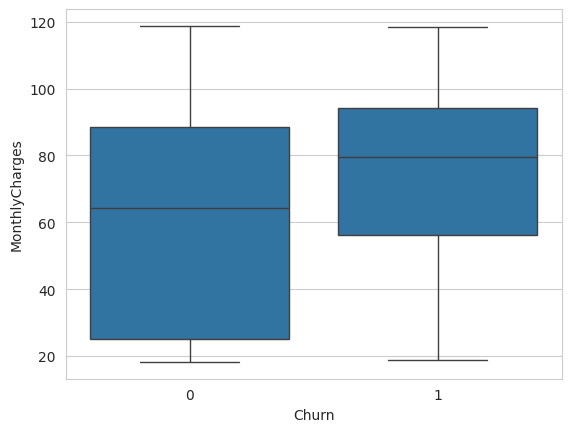

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

-   insight:High charges → higher churn

Payment Method vs Churn

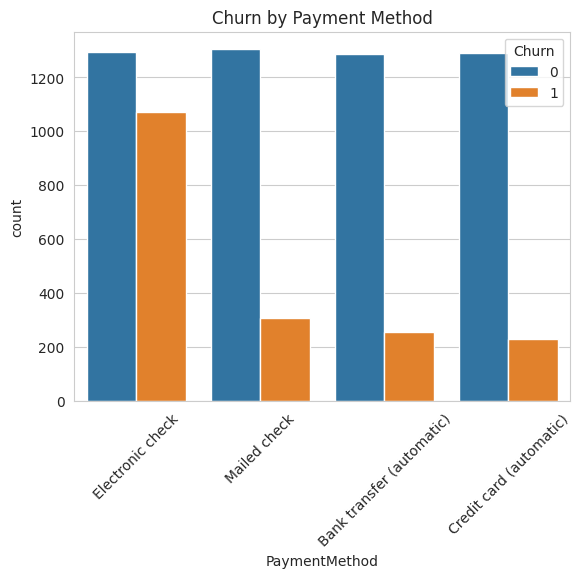

In [ ]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

-    insight: Electronic check users show highest churn

Tech Support Availability vs Churn

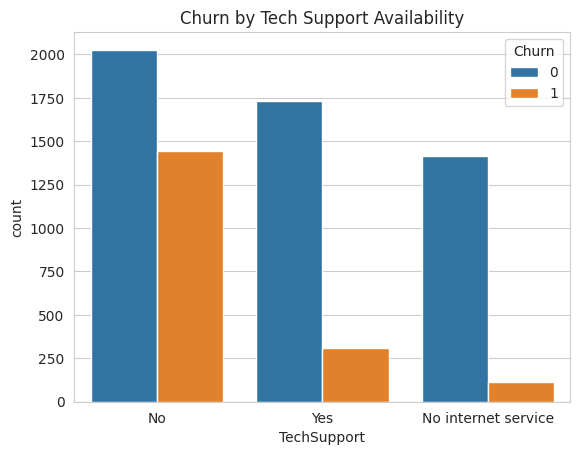

In [ ]:
sns.countplot(x="TechSupport", hue="Churn", data=df)

plt.title("Churn by Tech Support Availability")
plt.show()

-   insight: Customers without tech support churn more

Correlation Heatmap

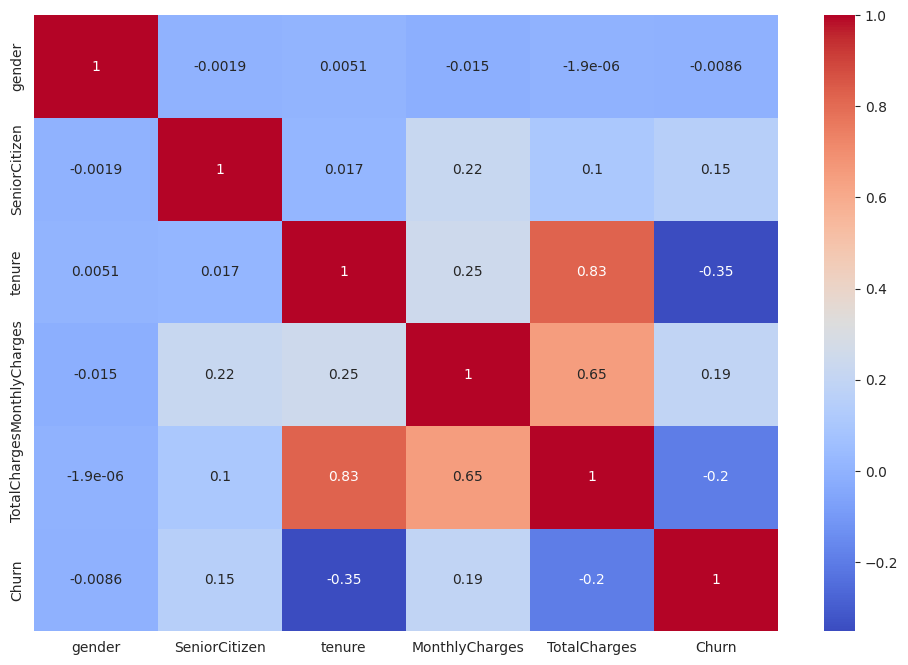

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

Explanaion of Correlation Heatmap

* Tenure (-0.35): Shows the strongest negative correlation with churn, indicating that longer-term customers are significantly less likely to leave.
* Monthly Charges (0.19): Displays a positive correlation with churn, suggesting that higher monthly costs are a contributing factor to customer loss.
* Senior Citizen (0.15): Indicates a slight positive relationship, meaning senior citizens in this dataset have a higher tendency to churn.
* Gender (-0.0086): Shows a near-zero correlation, proving that gender has no statistically significant impact on customer churn.
* Relationship Scale: The color gradient from dark blue (-1) to dark red (+1) visualizes the strength of these linear relationships across all variables.

Conclusion:


Based on the correlation analysis, the primary driver for customer retention is Tenure, as long-term customers demonstrate significantly higher loyalty, while higher Monthly Charges and Senior Citizen status are the most notable risk factors for churn. Consequently, business strategies should focus on loyalty programs to increase customer lifespan and personalized pricing plans to mitigate the churn risk associated with high monthly costs.





**variables strongly influence churn**

-   Customers with month-to-month contracts have the highest churn rate.
         
Reason:
They are not locked into long-term commitments and can leave anytime.

-   Customers with low tenure (0–12 months) churn the most.

Reason:
New customers are still evaluating service quality and pricing.


-   Customers paying higher monthly charges churn more frequently.

Reason:
High pricing increases dissatisfaction risk.

-   Fiber optic users show higher churn compared to DSL users.

Reason:
Usually linked with higher cost or service expectations.


-   Customers using electronic check payment churn more often.

Reason:
Often associated with lower engagement or automatic billing absence.


-   Customers without tech support churn more frequently.

Reason:
Support availability improves customer satisfaction and retention.

conclusion :

Contract type, tenure, monthly charges, internet service type, payment method, and tech support availability are the strongest variables influencing churn, with month-to-month contracts and low-tenure customers showing the highest churn risk.

Feature Engineering

In [ ]:
#Create tenure groups

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,60,72],
    labels=["0-1yr","1-2yr","2-4yr","4-5yr","5-6yr"]
)

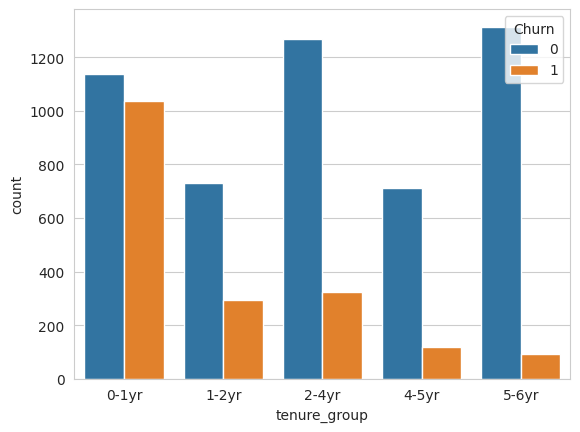

In [ ]:
#Check distribution

sns.countplot(x="tenure_group", hue="Churn", data=df)
plt.show()

Tenure-based customer segments using feature engineering helps to identify churn behavior across customer lifecycle stages. It helped reveal that early-stage customers have higher churn probability compared to long-term subscribers.

Export clean dataset for PowerBI

In [ ]:
df.to_csv("cleaned_churn_data.csv", index=False)

#Download file
from google.colab import files
files.download("cleaned_churn_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>